# 03 — H3 security / material audit (human review)

Functional classification: emotional security vs material/economic security vs status
display. Classify interaction **function**, not the object mentioned (a gown can be
status display, gift-as-care, or neither).

Saved Pass A/B/C + evidence packets only; rating cells stay blinded.
Special focus: leaf `1.6` (appearance) — Stage 10 found it on-label but the H3 question
is whether appearance content is doing *security* work.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("03_h3_security_material_audit")
cfg = ctx.cfg
HYP = "H3"
CODE_COL = "security_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit


## 1. Overview — every H3 topic with labels

In [2]:
master = nh.load_master(cfg)
h3 = master[master[CODE_COL].notna()].copy()
h3["code_norm"] = h3[CODE_COL].map(normalize_code)
print(f"H3-coded topics: {len(h3)}")

overview = rd.annotation_overview(h3, CODE_COL, extra_cols=["secondary_id"])
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]].head(60))
ctx.save_table(overview, "h3_topic_overview_labeled")
display(h3[CODE_COL].value_counts().head(20).to_frame("n"))
display(h3["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H3-coded topics: 82


,topic,taxonomy,code,code_norm,mixed,agree
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,H3


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_topic_overview_labeled.csv  (82 rows)


,n
security_code,
UNKNOWN,56
MIXED,26


,n_norm
code_norm,
None,82


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h3, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h3_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    print(f"Disagreements: {len(disagree)}")
    display(
        disagree[
            ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_a", "rationale_b"]
        ].head(30)
    )

Lexical–contextual agreement: 23.2% (19/82)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_lexical_contextual_agreement.csv  (82 rows)
Disagreements: 63


,topic,taxonomy,code_a,code_b,code_c,rationale_a,rationale_b
0,6 — Whispered Reassurance,"4.6 — Emotional Safety, Reassurance & Caretaking",emotional,CELL_D,UNKNOWN,All four representational layers converge on e...,"CELL_D fragments are the most numerous, charac..."
1,17 — Discussing Rooms and Privacy,8.1 — Domestic Spaces & Routines,material,MIXED,MIXED,All four lexical representations converge on m...,
2,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,status/appearance,UNKNOWN,UNKNOWN,All four lexical representations converge stro...,
3,27 — Racing The Approaching Storm,"7.3 — Risk, Danger & External Crises",E,MIXED,MIXED,All four representational layers converge on e...,
4,29 — Confessing Long-Held Love,"4.5 — Reconciliation, Commitments & HEA",emotional,MIXED,MIXED,Lexical field converges strongly on emotional ...,
5,31 — Keeping Watch While Others Sleep,"4.6 — Emotional Safety, Reassurance & Caretaking",material,emotional,UNKNOWN,Lexical signals across all representers conver...,All sentences across all cells and books clust...
6,36 — Eagerly Offering to Help,"4.6 — Emotional Safety, Reassurance & Caretaking",material,MIXED,MIXED,Lexical convergence across all four representa...,
7,38 — Admitting Shared Pain,4.2 — Ongoing Courtship & Everyday Relational ...,emotional,CELL_A,UNKNOWN,Signals across all extraction methods converge...,"CELL_A sentences cluster around shared, mutual..."
8,45 — Reassured Everything Will Be Fine,"4.6 — Emotional Safety, Reassurance & Caretaking",EMO,MIXED,MIXED,Lexical cluster centers on reassurance and soo...,
9,46 — Asking Someone to Trust You,"4.6 — Emotional Safety, Reassurance & Caretaking",ES,CELL_B,UNKNOWN,The lexical profile centers on trust and betra...,CELL_B dominates with direct interpersonal tru...


## 3. Appearance leaf (`1.6`) functional decomposition

What to check in the cards: is the prose describing bodies/clothes as craft ornament,
as wealth/status signalling, or as care/security? The object in the sentence is not the
construct.

In [4]:
app = h3[h3["current_taxonomy_id"] == "1.6"].copy()
print(f"Appearance topics in H3 audit: {len(app)}")
app_overview = rd.annotation_overview(app, CODE_COL, extra_cols=["secondary_id"])
display(app_overview[["topic", "taxonomy", "code", "code_norm", "mixed", "secondary_id"]])
ctx.save_table(app_overview, "h3_appearance_decomposition")

cross = (
    h3.assign(
        taxonomy=h3.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        )
    )
    .groupby(["taxonomy", "current_taxonomy_id", "code_norm"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(cross.head(40))
ctx.save_table(cross, "h3_taxonomy_vs_code")

Appearance topics in H3 audit: 15


,topic,taxonomy,code,code_norm,mixed,secondary_id
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,6.6
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,None
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,None
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,4.2
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,None
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,8.2
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,MIXED,None,True,4.2
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,3.2
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,3.2
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,UNKNOWN,None,False,None


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_appearance_decomposition.csv  (15 rows)


,taxonomy,current_taxonomy_id,code_norm,n
3,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,NaN,30
0,1.6 — Character Appearance & Self-Presentation,1.6,NaN,15
1,4.2 — Ongoing Courtship & Everyday Relational ...,4.2,NaN,14
2,"4.5 — Reconciliation, Commitments & HEA",4.5,NaN,8
11,"8.2 — Public, Travel & Leisure Spaces",8.2,NaN,4
5,"5.1 — Family, Kinship & Parenthood",5.1,NaN,3
4,4.7 — Jealousy & Possessive Romance Conflict,4.7,NaN,2
6,5.3a — Romantic Social Rituals & Public Couple...,5.3a,NaN,1
7,"6.4 — Economic Precarity, Security & Dependency",6.4,NaN,1
8,6.6 — Material Glamour & Consumption,6.6,NaN,1


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_taxonomy_vs_code.csv  (13 rows)


## 4. Close reading

Priority: appearance topics, disagreements, mixed, then stratified sample by code.

Close-reading 71 of 82 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 18 — Ordering A Gown For Her
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : UNKNOWN
  Stage08 snippets:
      · he’ll make sure you have a dress worthy of you.”
      · i’ll order a gown for you and have it sent to the house.” “
      · we’ll have to borrow their clothes.” “
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=middle, p=0.63]
        I did not mean to hurt your feelings about your attention to the womanly details of
        dress and appearance and wished to compensate you for the loss of the gown you’ve
        been wearing to work with Wilfrid.”
    · [BOOK_001, CELL_D, tertile=end, p=0.60]
        Mayhap if you were clothed when you attempted it, Edmee might have accepted it?” “’
    · [BOOK_001, CELL_D, tertile=middle, p=0.57]
        Her gown should be clean and her hair always groomed and under a veil. “
    · [BOOK_002, CELL_C, tertile=middle, p=

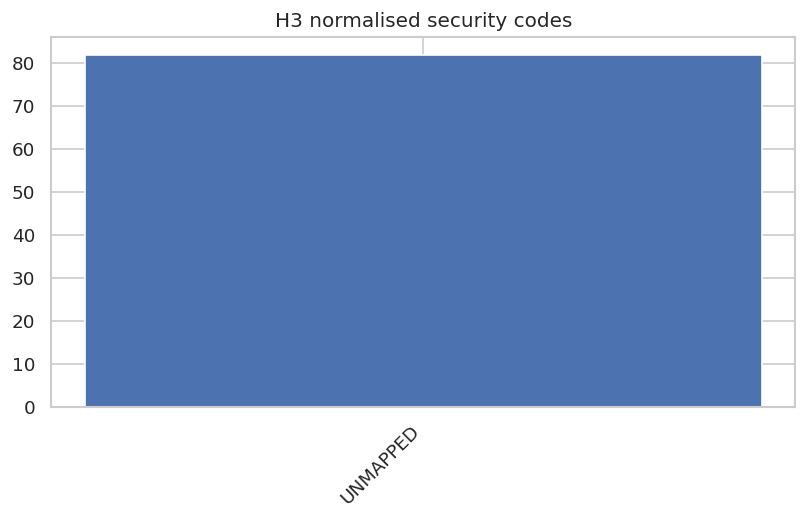

H3 audit review complete.


In [5]:
review_ids = rd.select_review_topics(
    h3,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=app["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h3,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H3 security / material — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h3[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "security_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "security_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h3["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H3 normalised security codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h3_code_distribution")
plt.show()

print("H3 audit review complete.")